In [26]:
import os
import urllib.request
import zipfile
import tarfile
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import csv
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

print("PyTorch verzija: " + torch.__version__)

# Postavljanje uređaja (GPU ako je dostupan, inače CPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Uređaj za treniranje: {device}")

PyTorch verzija: 2.10.0+cu128
Uređaj za treniranje: cuda:0


In [27]:
########################################################################################################################
# 1. MONTIRANJE GOOGLE DRIVE-A I PODEŠAVANJE PUTANJA
########################################################################################################################

from google.colab import drive
drive.mount('/content/drive')

# Putanja na Google Drive-u gde će se čuvati rezultati
drive_results_folder = '/content/drive/MyDrive/Caltech101_Results_PyTorch'
if not os.path.exists(drive_results_folder):
    os.makedirs(drive_results_folder)
    print(f"Napravljen direktorijum za rezultate na Drive-u: {drive_results_folder}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
########################################################################################################################
# 2. PREUZIMANJE I RASPAKIVANJE PODATAKA
########################################################################################################################

dataset_url = "https://data.caltech.edu/records/mzrjq-6wc02/files/caltech-101.zip"
zip_path = "/content/caltech-101.zip"
caltech_folder = "/content/caltech-101"
data_folder = "/content/101_ObjectCategories"

if not os.path.exists(zip_path):
    print("Preuzimanje dataseta...")
    urllib.request.urlretrieve(dataset_url, zip_path)
    print("Preuzimanje završeno.")

if not os.path.exists(caltech_folder):
    print("Raspakivanje osnovne ZIP arhive...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/')

if not os.path.exists(data_folder):
    print("Raspakivanje slika iz TAR.GZ arhive...")
    tar_path = os.path.join(caltech_folder, '101_ObjectCategories.tar.gz')
    with tarfile.open(tar_path, 'r:gz') as tar_ref:
        tar_ref.extractall('/content/')
    print("Slike su spremne.")

In [29]:
########################################################################################################################
# 3. FUNKCIJA ZA UČITAVANJE PODATAKA
########################################################################################################################

def load_data(image_size, keep_aspect=True, fill_value=0):
    categories = []
    train_data = []
    test_data = []

    image_folders = sorted(os.listdir(data_folder))
    for c in image_folders:
        if c == 'BACKGROUND_Google':
            continue

        path = os.path.join(data_folder, c)
        if os.path.isdir(path):
            categories.append(c)
            cnt = 0
            files = sorted(os.listdir(path))
            for f in files:
                image_file = os.path.join(path, f)
                if os.path.isfile(image_file):
                    if cnt % 5 == 2:
                        test_data.append((image_file, categories.index(c)))
                    else:
                        train_data.append((image_file, categories.index(c)))
                    cnt += 1

    x_train = np.zeros((len(train_data), image_size, image_size, 3), np.uint8)
    y_train = np.zeros((len(train_data), 1), np.uint8)
    x_test = np.zeros((len(test_data), image_size, image_size, 3), np.uint8)
    y_test = np.zeros((len(test_data), 1), np.uint8)

    for i in range(len(train_data)):
        file, c = train_data[i]
        y_train[i] = c
        img = cv.imread(file)
        if img is None:
            continue
        if keep_aspect:
            cy, cx = img.shape[:2]
            if cx > cy:
                d = cx - cy
                img = cv.copyMakeBorder(img, top=d//2, bottom=d-d//2, left=0, right=0,
                                        borderType=cv.BORDER_CONSTANT, value=fill_value)
            else:
                d = cy - cx
                img = cv.copyMakeBorder(img, top=0, bottom=0, left=d//2, right=d-d//2,
                                        borderType=cv.BORDER_CONSTANT, value=fill_value)
        img = cv.resize(img, (image_size, image_size), interpolation=cv.INTER_LINEAR)
        x_train[i] = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    for i in range(len(test_data)):
        file, c = test_data[i]
        y_test[i] = c
        img = cv.imread(file)
        if img is None:
            continue
        if keep_aspect:
            cy, cx = img.shape[:2]
            if cx > cy:
                d = cx - cy
                img = cv.copyMakeBorder(img, top=d//2, bottom=d-d//2, left=0, right=0,
                                        borderType=cv.BORDER_CONSTANT, value=fill_value)
            else:
                d = cy - cx
                img = cv.copyMakeBorder(img, top=0, bottom=0, left=d//2, right=d-d//2,
                                        borderType=cv.BORDER_CONSTANT, value=fill_value)
        img = cv.resize(img, (image_size, image_size), interpolation=cv.INTER_LINEAR)
        x_test[i] = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    rand_train_idx = np.random.RandomState(seed=0).permutation(len(train_data))
    x_train = x_train[rand_train_idx]
    y_train = y_train[rand_train_idx]

    rand_test_idx = np.random.RandomState(seed=0).permutation(len(test_data))
    x_test = x_test[rand_test_idx]
    y_test = y_test[rand_test_idx]

    return categories, x_train, y_train, x_test, y_test

In [30]:
########################################################################################################################
# 4. KREIRANJE MODELA
########################################################################################################################

def create_model(classes, trainable_encoder=False):
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    model = models.efficientnet_b0(weights=weights)

    if not trainable_encoder:
        # 1. Prvo zamrznemo sve parametre
        for param in model.parameters():
            param.requires_grad = False

        # 2. Zatim prođemo kroz sve module i ODMRZNEMO Batch Normalization (kao u Kerasu)
        for module in model.modules():
            if isinstance(module, nn.BatchNorm2d):
                for param in module.parameters():
                    param.requires_grad = True

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.5, inplace=True),
        nn.Linear(in_features, classes)
    )

    return model

Učitavanje i pretprocesiranje slika...
Oblik trening skupa: (6941, 224, 224, 3) (6941, 1)
Oblik test skupa: (1736, 224, 224, 3) (1736, 1)
Broj kategorija: 101

Prikaz prvih 10 slika iz trening skupa...


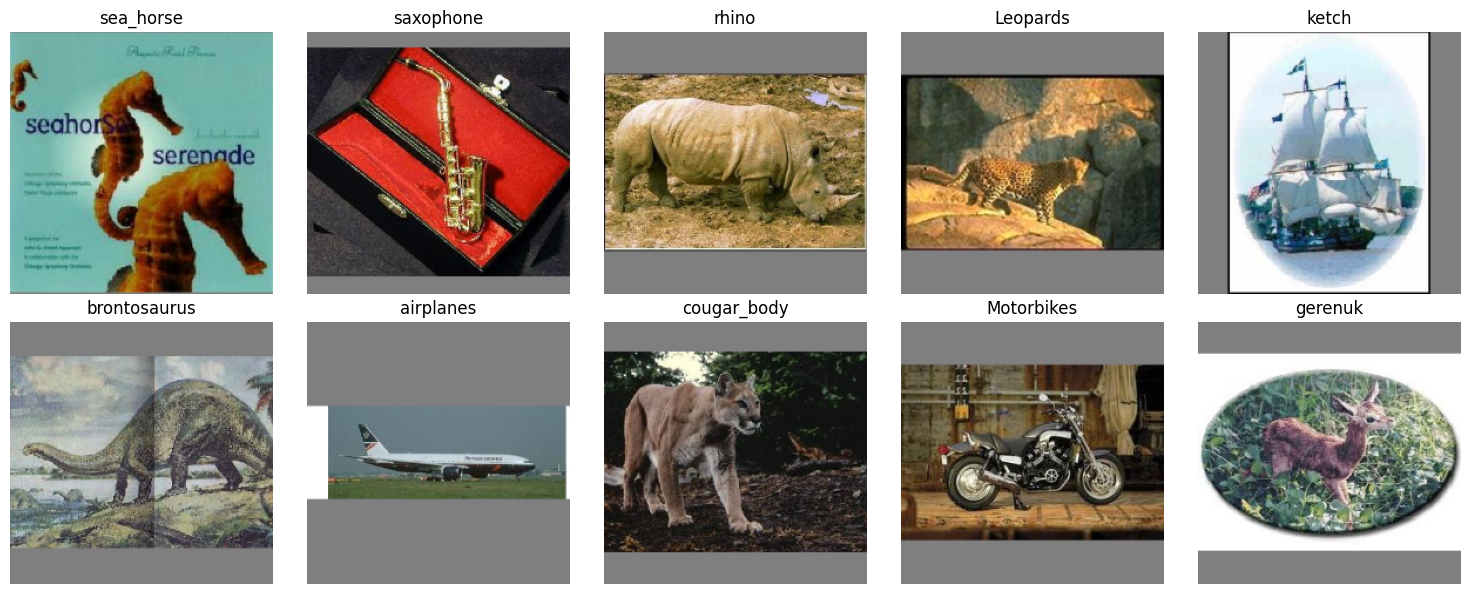

In [31]:
########################################################################################################################
# 5. UČITAVANJE I PRETPROCESIRANJE PODATAKA
########################################################################################################################

image_size = 224
batch_size = 32

print("Učitavanje i pretprocesiranje slika...")
categories, x_train, y_train, x_test, y_test = load_data(image_size, keep_aspect=True, fill_value=(127, 127, 127))
print("Oblik trening skupa:", x_train.shape, y_train.shape)
print("Oblik test skupa:", x_test.shape, y_test.shape)
print("Broj kategorija:", len(categories))

print("\nPrikaz prvih 10 slika iz trening skupa...")
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    class_index = int(y_train[i][0])
    plt.title(categories[class_index])
    plt.axis('off')
plt.tight_layout()
plt.show()

# Kreiranje PyTorch Dataset klase
class CaltechDataset(Dataset):
    def __init__(self, x_data, y_data):
        self.x_data = x_data
        self.y_data = y_data.flatten()
        # Pretprocesiranje koje je podrazumevano za predtrenirane modele u PyTorch-u
        self.transform = transforms.Compose([
            transforms.ToTensor(), # Pretvara HWC uint8 [0,255] u CHW float32 [0.0, 1.0]
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.x_data)

    def __getitem__(self, idx):
        img = self.x_data[idx]
        label = self.y_data[idx]
        img_tensor = self.transform(img)
        return img_tensor, torch.tensor(label, dtype=torch.long)

train_dataset = CaltechDataset(x_train, y_train)
test_dataset = CaltechDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [32]:
########################################################################################################################
# 6. KREIRANJE MODELA I PRIPREMA ZA OBUČAVANJE
########################################################################################################################

model = create_model(classes=len(categories), trainable_encoder=False)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ReduceLROnPlateau ekvivalent
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=10)

# Za praćenje metrika
history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}
csv_path = os.path.join(drive_results_folder, 'training.csv')

In [33]:
########################################################################################################################
# 7. OBUČAVANJE MODELA SA EARLY STOPPING-OM
########################################################################################################################

print("Početak treniranja...")

epochs = 1000
early_stopping_patience = 30
epochs_no_improve = 0
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['epoch', 'loss', 'accuracy', 'val_loss', 'val_accuracy', 'lr'])

    for epoch in range(epochs):
        # ---------------- TRENING FAZA ----------------
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = running_corrects.double().item() / len(train_dataset)

        # ---------------- VALIDACIONA FAZA ----------------
        model.eval()
        val_loss = 0.0
        val_corrects = 0

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        val_epoch_loss = val_loss / len(test_dataset)
        val_epoch_acc = val_corrects.double().item() / len(test_dataset)

        # Čuvanje u memoriji i pisanje u CSV
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        history['val_loss'].append(val_epoch_loss)
        history['val_accuracy'].append(val_epoch_acc)

        current_lr = optimizer.param_groups[0]['lr']
        writer.writerow([epoch, epoch_loss, epoch_acc, val_epoch_loss, val_epoch_acc, current_lr])
        print(f'Epoch {epoch+1:03d}: Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} || Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc:.4f} || LR: {current_lr:.8f}')

        # Prilagođavanje stope učenja (Learning Rate)
        scheduler.step(val_epoch_acc)

        # ---------------- EARLY STOPPING LOGIKA ----------------
        if val_epoch_acc > best_val_acc:
            best_val_acc = val_epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= early_stopping_patience:
                print(f"Rano zaustavljanje (Early stopping) pokrenuto nakon epohe {epoch+1}")
                break

# Učitavanje najboljih težina
model.load_state_dict(best_model_wts)

# Čuvanje modela
model_path = os.path.join(drive_results_folder, 'trained_model.pth')
torch.save(model.state_dict(), model_path)
print(f"\nModel sačuvan na: {model_path}")

Početak treniranja...
Epoch 001: Loss: 1.9008 | Acc: 0.6452 || Val Loss: 0.5543 | Val Acc: 0.8980 || LR: 0.00100000
Epoch 002: Loss: 0.3731 | Acc: 0.9195 || Val Loss: 0.2597 | Val Acc: 0.9401 || LR: 0.00100000
Epoch 003: Loss: 0.2114 | Acc: 0.9463 || Val Loss: 0.2123 | Val Acc: 0.9459 || LR: 0.00100000
Epoch 004: Loss: 0.1513 | Acc: 0.9587 || Val Loss: 0.1926 | Val Acc: 0.9441 || LR: 0.00100000
Epoch 005: Loss: 0.1175 | Acc: 0.9690 || Val Loss: 0.1698 | Val Acc: 0.9533 || LR: 0.00100000
Epoch 006: Loss: 0.0986 | Acc: 0.9744 || Val Loss: 0.1620 | Val Acc: 0.9579 || LR: 0.00100000
Epoch 007: Loss: 0.0780 | Acc: 0.9810 || Val Loss: 0.1565 | Val Acc: 0.9574 || LR: 0.00100000
Epoch 008: Loss: 0.0680 | Acc: 0.9816 || Val Loss: 0.1584 | Val Acc: 0.9556 || LR: 0.00100000
Epoch 009: Loss: 0.0593 | Acc: 0.9846 || Val Loss: 0.1522 | Val Acc: 0.9579 || LR: 0.00100000
Epoch 010: Loss: 0.0553 | Acc: 0.9846 || Val Loss: 0.1598 | Val Acc: 0.9533 || LR: 0.00100000
Epoch 011: Loss: 0.0459 | Acc: 0.9883 

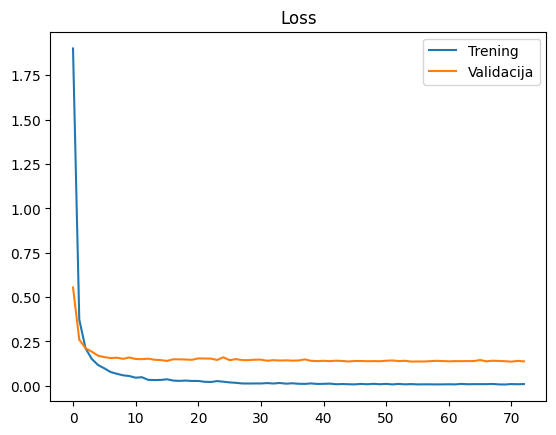

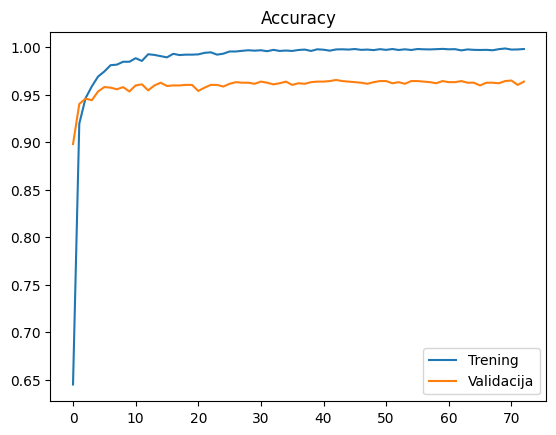

In [34]:
########################################################################################################################
# 8. PRIKAZ I ČUVANJE GRAFIKA
########################################################################################################################

plt.clf()
plt.plot(history['loss'], label='Trening')
plt.plot(history['val_loss'], label='Validacija')
plt.legend()
plt.title('Loss')
plt.savefig(os.path.join(drive_results_folder, 'training_loss.png'))
plt.show()

plt.clf()
plt.plot(history['accuracy'], label='Trening')
plt.plot(history['val_accuracy'], label='Validacija')
plt.legend()
plt.title('Accuracy')
plt.savefig(os.path.join(drive_results_folder, 'training_accuracy.png'))
plt.show()


Sakupljanje predikcija na test skupu...
Finalna test tačnost: 0.9654

Pogrešne predikcije (60 komada) su sačuvane na Drive-u u folderu: /content/drive/MyDrive/Caltech101_Results_PyTorch/misclassified

Prikaz prvih (do 25) loše klasifikovanih slika:


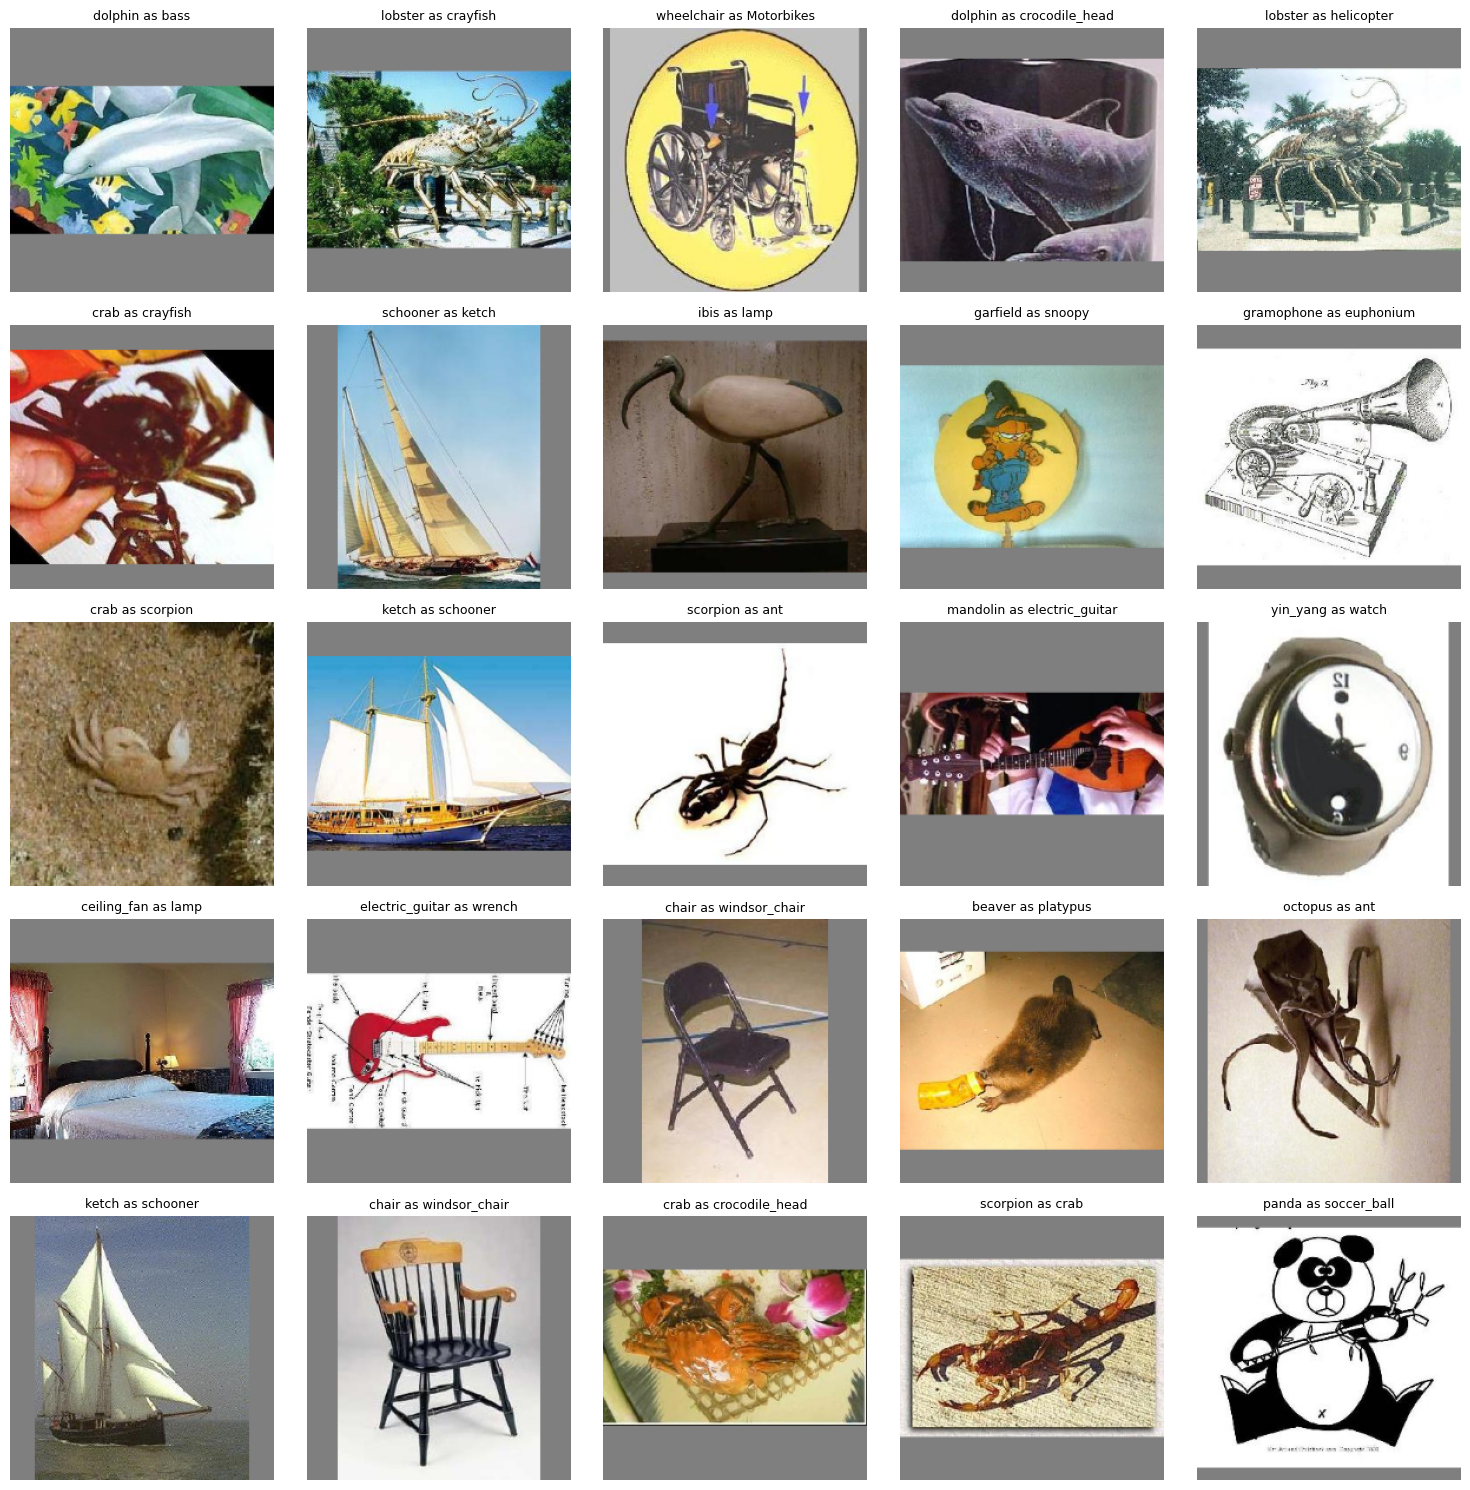

In [35]:
########################################################################################################################
# 9. EVALUACIJA MODELA
########################################################################################################################

print("\nSakupljanje predikcija na test skupu...")
model.eval()
all_preds = []

with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())

y_out = np.array(all_preds)
y_test_flat = y_test.flatten()

# Izračunavanje finalne tačnosti na osnovu sakupljenih predikcija
test_accuracy = np.sum(y_out == y_test_flat) / len(y_test_flat)
print(f"Finalna test tačnost: {test_accuracy:.4f}")

misclassified_folder = os.path.join(drive_results_folder, 'misclassified')
if not os.path.exists(misclassified_folder):
    os.makedirs(misclassified_folder)

i = 0
misclassified_for_grid = []

for img, out, exp in zip(x_test, y_out, y_test_flat):
    if out != exp:
        i += 1
        title = '{} as {}'.format(categories[int(exp)], categories[int(out)])

        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.title(title)
        plt.savefig(os.path.join(misclassified_folder, '{} ({}).jpg'.format(i, title)))
        plt.close()

        if len(misclassified_for_grid) < 25:
            misclassified_for_grid.append((img, title))

print(f"\nPogrešne predikcije ({i} komada) su sačuvane na Drive-u u folderu: {misclassified_folder}")

if misclassified_for_grid:
    print("\nPrikaz prvih (do 25) loše klasifikovanih slika:")
    cols = 5
    rows = min(5, (len(misclassified_for_grid) + cols - 1) // cols)

    plt.figure(figsize=(15, 3 * rows))
    for idx, (img, title) in enumerate(misclassified_for_grid):
        plt.subplot(rows, cols, idx + 1)
        plt.imshow(img)
        plt.title(title, fontsize=9)
        plt.axis('off')

    plt.tight_layout()
    plt.show()